# So sánh kết quả với Paper

Chọn cấu hình tầng 1 `['x', 'y']` tốt nhất từ Grid Search, sau đó so sánh với Paper ở cả mức tổng thể và F1 của từng nhãn.

In [18]:
import ast
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

working_dir = Path.cwd().resolve()
search_roots = [working_dir, *working_dir.parents]
csv_candidates = []
for root in search_roots:
    for candidate in (root / 'grid_search_results.csv', root / 'eyemovement' / 'grid_search_results.csv'):
        if candidate.exists():
            csv_candidates.append(candidate)
if not csv_candidates:
    for root in search_roots[:3]:
        csv_candidates.extend(root.glob('**/grid_search_results.csv'))
if not csv_candidates:
    raise FileNotFoundError(f'Không tìm thấy grid_search_results.csv. Thư mục kernel hiện tại: {working_dir}')

GRID_PATH = str(csv_candidates[0].resolve())
BASE_DIR = os.path.dirname(GRID_PATH)
grid = pd.read_csv(GRID_PATH)
grid['_features'] = grid['L1_FEATURES'].map(ast.literal_eval)
xy_grid = grid[grid['_features'].map(lambda features: features == ['x', 'y'])].copy()
if xy_grid.empty:
    raise ValueError("Không có cấu hình nào dùng L1_FEATURES = ['x', 'y']")
best = xy_grid.sort_values(by=['Mean_Accuracy', 'Mean_F1'], ascending=False).iloc[0]
required_label_columns = [
    f'{metric}_{label}'
    for label in ['Fixation', 'Smooth_Pursuit', 'Saccade']
    for metric in ['Precision', 'Recall', 'F1']
]
missing_label_columns = [column for column in required_label_columns if column not in grid.columns]
if missing_label_columns:
    raise ValueError(
        'grid_search_results.csv chưa có metric từng nhãn. '
        'Hãy chạy lại toàn bộ hyperparametter.ipynb trước. '
        f'Thiếu: {missing_label_columns}'
    )


In [19]:
paper = {'Accuracy': 0.9439, 'Precision': 0.9531, 'Recall': 0.9498, 'F1': 0.9492}
current = {'Accuracy': best['Mean_Accuracy'], 'Precision': best['Mean_Precision'], 'Recall': best['Mean_Recall'], 'F1': best['Mean_F1']}
comparison = pd.DataFrame({'Metric': list(current), 'Grid search': [current[m] for m in current], 'Paper': [paper[m] for m in current]})
comparison['Difference (percentage points)'] = (comparison['Grid search'] - comparison['Paper']) * 100

paper_by_label = {
    'Fixation': {'Precision': 0.9743, 'Recall': 0.9665, 'F1': 0.9699},
    'Smooth Pursuit': {'Precision': 0.8784, 'Recall': 0.9076, 'F1': 0.8893},
    'Saccade': {'Precision': 0.9301, 'Recall': 0.8967, 'F1': 0.9077},
}
label_rows = []
for label, prefix in [('Fixation', 'Fixation'), ('Smooth Pursuit', 'Smooth_Pursuit'), ('Saccade', 'Saccade')]:
    for metric in ['Precision', 'Recall', 'F1']:
        grid_value = best[f'{metric}_{prefix}']
        paper_value = paper_by_label[label][metric]
        label_rows.append({'Label': label, 'Metric': metric, 'Grid search': grid_value, 'Paper': paper_value, 'Difference (percentage points)': (grid_value - paper_value) * 100})
label_comparison = pd.DataFrame(label_rows)

display(best[['L1_FEATURES', 'COV_TYPE', 'N_MIX', 'MIN_SEG_LEN', 'STANDARDIZE']].to_frame('Value'))
display(comparison.assign(**{
    'Grid search': comparison['Grid search'].map(lambda v: f'{v:.2%}'),
    'Paper': comparison['Paper'].map(lambda v: f'{v:.2%}'),
    'Difference (percentage points)': comparison['Difference (percentage points)'].map(lambda v: f'{v:+.2f}'),
}))
display(label_comparison.assign(**{
    'Grid search': label_comparison['Grid search'].map(lambda v: f'{v:.2%}'),
    'Paper': label_comparison['Paper'].map(lambda v: f'{v:.2%}'),
    'Difference (percentage points)': label_comparison['Difference (percentage points)'].map(lambda v: f'{v:+.2f}'),
}))

,Value
L1_FEATURES,"['x', 'y']"
COV_TYPE,spherical
N_MIX,1
MIN_SEG_LEN,10
STANDARDIZE,False


,Metric,Grid search,Paper,Difference (percentage points)
0,Accuracy,87.07%,94.39%,-7.32
1,Precision,85.06%,95.31%,-10.25
2,Recall,84.22%,94.98%,-10.76
3,F1,82.96%,94.92%,-11.96


,Label,Metric,Grid search,Paper,Difference (percentage points)
0,Fixation,Precision,93.48%,97.43%,-3.95
1,Fixation,Recall,92.84%,96.65%,-3.81
2,Fixation,F1,92.60%,96.99%,-4.39
3,Smooth Pursuit,Precision,73.51%,87.84%,-14.33
4,Smooth Pursuit,Recall,77.91%,90.76%,-12.85
5,Smooth Pursuit,F1,74.02%,88.93%,-14.91
6,Saccade,Precision,88.19%,93.01%,-4.82
7,Saccade,Recall,81.90%,89.67%,-7.77
8,Saccade,F1,82.24%,90.77%,-8.53


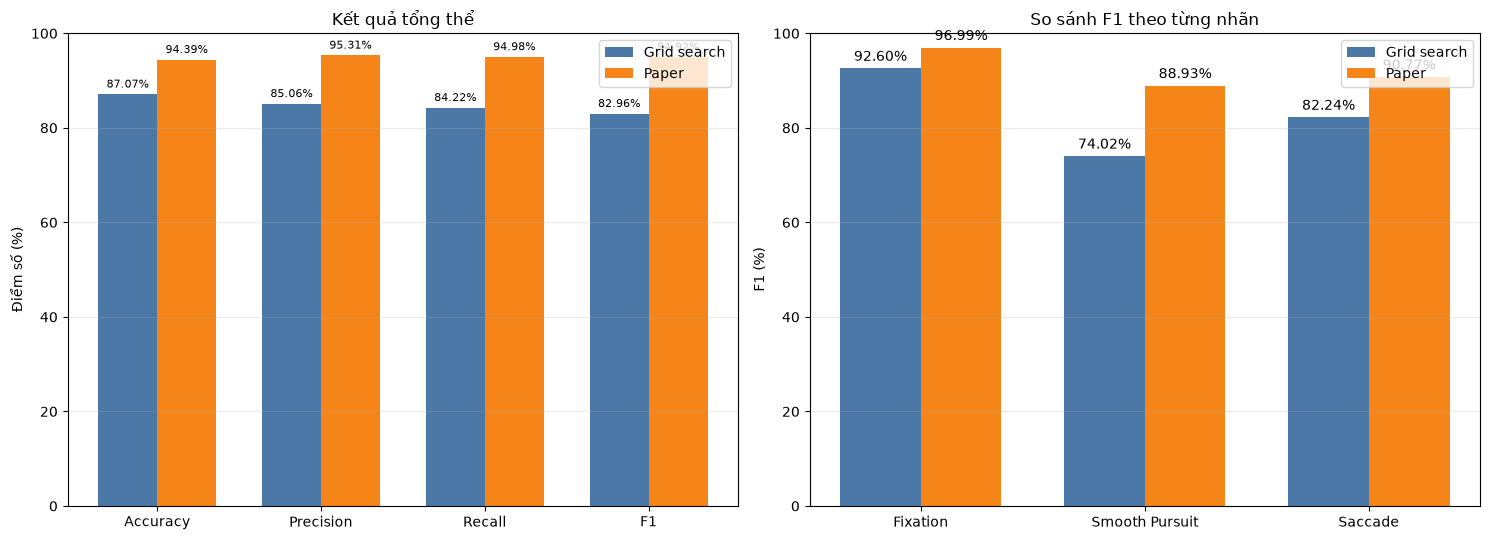

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
x = np.arange(len(comparison))
width = 0.36
overall_grid_bars = axes[0].bar(x - width / 2, comparison['Grid search'] * 100, width, label='Grid search', color='#4C78A8')
overall_paper_bars = axes[0].bar(x + width / 2, comparison['Paper'] * 100, width, label='Paper', color='#F58518')
axes[0].bar_label(overall_grid_bars, labels=[f'{value:.2f}%' for value in comparison['Grid search'] * 100], padding=3, fontsize=8)
axes[0].bar_label(overall_paper_bars, labels=[f'{value:.2f}%' for value in comparison['Paper'] * 100], padding=3, fontsize=8)
axes[0].set_title('Kết quả tổng thể')
axes[0].set_ylabel('Điểm số (%)')
axes[0].set_xticks(x, comparison['Metric'])
axes[0].set_ylim(0, 100)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.25)

labels = ['Fixation', 'Smooth Pursuit', 'Saccade']
f1_columns = ['F1_Fixation', 'F1_Smooth_Pursuit', 'F1_Saccade']
label_f1_values = [best[column] * 100 for column in f1_columns]
paper_f1_values = [paper_by_label[label]['F1'] * 100 for label in labels]
x = np.arange(len(labels))
grid_bars = axes[1].bar(x - width / 2, label_f1_values, width, label='Grid search', color='#4C78A8')
paper_bars = axes[1].bar(x + width / 2, paper_f1_values, width, label='Paper', color='#F58518')
axes[1].set_title('So sánh F1 theo từng nhãn')
axes[1].set_ylabel('F1 (%)')
axes[1].set_xticks(x, labels)
axes[1].set_ylim(0, 100)
axes[1].bar_label(grid_bars, labels=[f'{value:.2f}%' for value in label_f1_values], padding=3)
axes[1].bar_label(paper_bars, labels=[f'{value:.2f}%' for value in paper_f1_values], padding=3)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

In [21]:
comparison.to_csv(os.path.join(BASE_DIR, 'xy_vs_paper_comparison.csv'), index=False)
label_comparison.to_csv(os.path.join(BASE_DIR, 'xy_vs_paper_per_label.csv'), index=False)
print('Đã lưu kết quả tổng thể và từng nhãn.')

Đã lưu kết quả tổng thể và từng nhãn.
